# SpillNet Case Study Figure Generator (Local)
**Instructions:**
1. Run all cells from top to bottom
2. To change sample: update `SAMPLE_NUMBER` in Cell 2 and re-run all cells

In [1]:
# ── Cell 1: PATHS ────────────────────────────────────────────────────────────
DATA_DIR   = r'C:\Users\Umaha\Documents\phd\Oil_Spill_Detection_Dataset'
MODEL_PATH = r'C:\Users\Umaha\Documents\phd\best_model.keras'
# MODEL_PATH = r'C:\Users\Umaha\Documents\phd\model.keras'

import os
print('DATA_DIR   exists:', os.path.exists(DATA_DIR))
print('MODEL_PATH exists:', os.path.exists(MODEL_PATH))

DATA_DIR   exists: False
MODEL_PATH exists: False


In [2]:
# ── Cell 2: USER SETTINGS — only change the number ───────────────────────────
SAMPLE_NUMBER    = '0017'       # <-- change ONLY this number
CASE_STUDY_TITLE = 'Case study 4b'  # <-- change label if needed

IMAGE_FILENAME = f'img_{SAMPLE_NUMBER}.jpg'
MASK_FILENAME  = f'img_{SAMPLE_NUMBER}.png'
OUTPUT_DIR     = os.path.join('results', 'case_study')
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH    = os.path.join(OUTPUT_DIR, f'case_study_{SAMPLE_NUMBER}.png')
print(f'Image : {IMAGE_FILENAME}')
print(f'Mask  : {MASK_FILENAME}')
print(f'Output: {OUTPUT_PATH}')

Image : img_0017.jpg
Mask  : img_0017.png
Output: case_study_0017.png


In [179]:
# ── Cell 3: Imports ───────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image
import tensorflow as tf
from tensorflow.keras.layers import Layer, GlobalAveragePooling2D, Dense, Reshape, Multiply
print('✅ Imports OK')

✅ Imports OK


In [180]:
# ── Cell 4: Custom objects needed to load SpillNet model ─────────────────────
class SimplifiedAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.global_pool = None
        self.fc1 = None
        self.fc2 = None

    def build(self, input_shape):
        channels = input_shape[-1]
        self.global_pool = GlobalAveragePooling2D(name=f'{self.name}_gap')
        self.fc1 = Dense(channels // 4, activation='relu', name=f'{self.name}_fc1')
        self.fc2 = Dense(channels, activation='sigmoid', name=f'{self.name}_fc2')
        self.fc1.build((None, channels))
        self.fc2.build((None, channels // 4))
        super().build(input_shape)

    def call(self, inputs):
        avg_pool = self.global_pool(inputs)
        attention = self.fc1(avg_pool)
        attention = self.fc2(attention)
        attention = Reshape((1, 1, -1))(attention)
        return Multiply()([inputs, attention])

    def get_config(self):
        return super().get_config()

    def compute_output_shape(self, input_shape):
        return input_shape

def oil_spill_recall(y_true, y_pred):
    y_pred_classes = tf.argmax(y_pred, axis=-1)
    y_true_classes = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
    true_c1 = tf.equal(y_true_classes, 1)
    pred_c1 = tf.equal(y_pred_classes, 1)
    tp = tf.reduce_sum(tf.cast(tf.logical_and(true_c1, pred_c1), tf.float32))
    total = tf.reduce_sum(tf.cast(true_c1, tf.float32))
    return tf.cond(total > 0, lambda: tp / total, lambda: 0.0)

def oil_spill_precision(y_true, y_pred):
    y_pred_classes = tf.argmax(y_pred, axis=-1)
    y_true_classes = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
    true_c1 = tf.equal(y_true_classes, 1)
    pred_c1 = tf.equal(y_pred_classes, 1)
    tp = tf.reduce_sum(tf.cast(tf.logical_and(true_c1, pred_c1), tf.float32))
    total = tf.reduce_sum(tf.cast(pred_c1, tf.float32))
    return tf.cond(total > 0, lambda: tp / total, lambda: 0.0)

def weighted_loss_fn(y_true, y_pred):
    class_weights = tf.constant([1.0, 15.0, 3.0, 30.0, 3.0], dtype=tf.float32)
    y_true_int = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
    sample_weights = tf.gather(class_weights, y_true_int)
    base_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return tf.reduce_mean(base_loss * sample_weights)

custom_objects = {
    'SimplifiedAttention': SimplifiedAttention,
    'oil_spill_recall': oil_spill_recall,
    'oil_spill_precision': oil_spill_precision,
    'loss_fn': weighted_loss_fn,
}
print('✅ Custom objects defined')

✅ Custom objects defined


In [181]:
# ── Cell 5: Config ────────────────────────────────────────────────────────────
IMG_SIZE    = 224
CLASS_NAMES = ['Sea Surface', 'Oil Spill', 'Look-alike', 'Ship', 'Land']
CLASS_RGB   = np.array([
    [0,   0,   0  ],   # 0: Sea Surface — black
    [0,   255, 255],   # 1: Oil Spill   — cyan
    [255, 0,   0  ],   # 2: Look-alike  — red
    [153, 76,  0  ],   # 3: Ship        — brown
    [0,   153, 0  ],   # 4: Land        — green
], dtype=np.uint8)
print('✅ Config OK')

✅ Config OK


In [182]:
# ── Cell 6: Find image and mask ───────────────────────────────────────────────
IMG_PATH, MASK_PATH = None, None
for split in ['test', 'train']:
    candidate_img  = os.path.join(DATA_DIR, split, 'images',    IMAGE_FILENAME)
    candidate_mask = os.path.join(DATA_DIR, split, 'labels_1D', MASK_FILENAME)
    if os.path.exists(candidate_img):
        IMG_PATH  = candidate_img
        MASK_PATH = candidate_mask
        print(f'✅ Found in {split} split')
        print(f'   Image: {IMG_PATH}')
        print(f'   Mask:  {MASK_PATH}')
        break

# Fallback: force test path
if IMG_PATH is None:
    IMG_PATH  = os.path.join(DATA_DIR, 'test', 'images',    IMAGE_FILENAME)
    MASK_PATH = os.path.join(DATA_DIR, 'test', 'labels_1D', MASK_FILENAME)
    print(f'⚠️  Loop failed — using test path directly')

print(f'Image exists: {os.path.exists(IMG_PATH)}')
print(f'Mask  exists: {os.path.exists(MASK_PATH)}')

if not os.path.exists(IMG_PATH):
    raise FileNotFoundError(f'Image not found: {IMG_PATH}')
if not os.path.exists(MASK_PATH):
    raise FileNotFoundError(f'Mask not found: {MASK_PATH}')

✅ Found in test split
   Image: C:\Users\Umaha\Documents\phd\Oil_Spill_Detection_Dataset\test\images\img_0017.jpg
   Mask:  C:\Users\Umaha\Documents\phd\Oil_Spill_Detection_Dataset\test\labels_1D\img_0017.png
Image exists: True
Mask  exists: True


In [183]:
# ── Cell 7: Load model ────────────────────────────────────────────────────────
print('Loading model...')
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objects)
print('✅ Model loaded')

Loading model...


✅ Model loaded


In [184]:
# ── Cell 8: Load image and mask, run inference ────────────────────────────────
img_pil     = Image.open(IMG_PATH).convert('RGB')
img_resized = img_pil.resize((IMG_SIZE, IMG_SIZE))
img_array   = np.array(img_resized, dtype=np.float32) / 255.0
img_batch   = img_array[np.newaxis, ...]

mask_pil = Image.open(MASK_PATH).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
gt_mask  = np.array(mask_pil)

print('Running inference...')
preds = model({'input_image': img_batch}, training=False)
if isinstance(preds, list):
    preds = preds[0]
preds = preds.numpy()[0]

pred_classes   = np.argmax(preds, axis=-1)
confidence_map = np.max(preds, axis=-1)
print('✅ Inference complete')

total_pixels = pred_classes.size
class_stats  = {}
for i in range(5):
    mask_i = pred_classes == i
    pct    = float(np.sum(mask_i) / total_pixels * 100)
    conf   = float(np.mean(confidence_map[mask_i])) if np.sum(mask_i) > 0 else 0.0
    class_stats[i] = {'name': CLASS_NAMES[i], 'percentage': pct, 'avg_confidence': conf}
    print(f'  Class {i} ({CLASS_NAMES[i]:12s}): {pct:6.2f}%  conf={conf:.3f}')

Running inference...
✅ Inference complete
  Class 0 (Sea Surface ):  90.35%  conf=0.822
  Class 1 (Oil Spill   ):   2.14%  conf=0.549
  Class 2 (Look-alike  ):   0.00%  conf=0.000
  Class 3 (Ship        ):   0.00%  conf=0.000
  Class 4 (Land        ):   7.51%  conf=0.691



✅ Figure saved to: case_study_0017.png


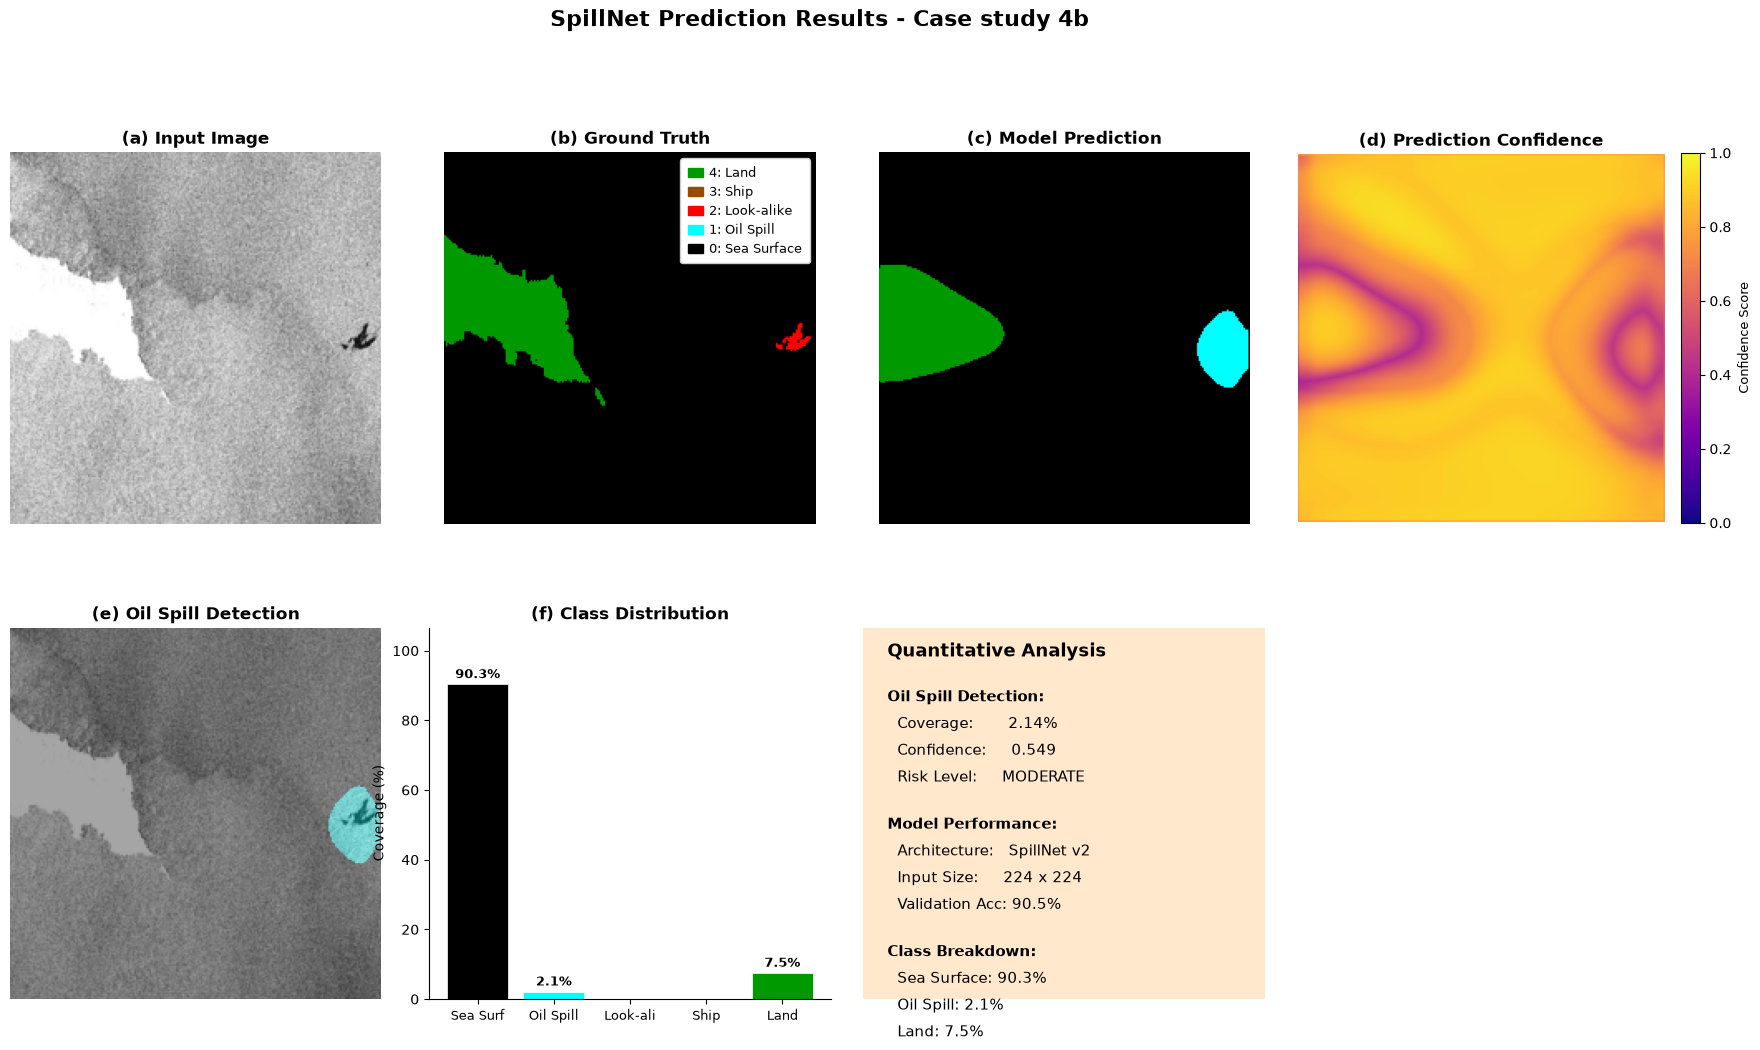

In [185]:
# ── Cell 9: Generate and save figure ─────────────────────────────────────────
def class_to_rgb(class_map):
    rgb = np.zeros((*class_map.shape, 3), dtype=np.uint8)
    for i in range(5):
        rgb[class_map == i] = CLASS_RGB[i]
    return rgb

gt_rgb   = class_to_rgb(gt_mask)
pred_rgb = class_to_rgb(pred_classes)

oil_overlay = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
oil_overlay[pred_classes == 1] = [0, 1, 1]
blended = np.clip(img_array * 0.65 + oil_overlay * 0.35, 0, 1)

oil_pct    = class_stats[1]['percentage']
oil_conf   = class_stats[1]['avg_confidence']
risk_level = ('HIGH'     if oil_pct > 5  and oil_conf > 0.7 else
               'MODERATE' if oil_pct > 1  and oil_conf > 0.5 else 'LOW')
risk_color = {'HIGH': '#FFCCCC', 'MODERATE': '#FFE8CC', 'LOW': '#CCFFCC'}[risk_level]

legend_patches = [
    mpatches.Patch(color=np.array(CLASS_RGB[i])/255, label=f'{i}: {CLASS_NAMES[i]}')
    for i in range(5)
]

fig = plt.figure(figsize=(22, 11))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.08, hspace=0.28)

ax_input  = fig.add_subplot(gs[0, 0])
ax_gt     = fig.add_subplot(gs[0, 1])
ax_pred   = fig.add_subplot(gs[0, 2])
ax_conf   = fig.add_subplot(gs[0, 3])
ax_detect = fig.add_subplot(gs[1, 0])
ax_dist   = fig.add_subplot(gs[1, 1])
ax_summ   = fig.add_subplot(gs[1, 2])
ax_empty  = fig.add_subplot(gs[1, 3])

fig.suptitle(f'SpillNet Prediction Results - {CASE_STUDY_TITLE}',
             fontsize=16, fontweight='bold', y=1.01)

ax_input.imshow(img_resized)
ax_input.set_title('(a) Input Image', fontsize=12, fontweight='bold')
ax_input.axis('off')

ax_gt.imshow(gt_rgb)
ax_gt.set_title('(b) Ground Truth', fontsize=12, fontweight='bold')
ax_gt.axis('off')
ax_gt.legend(handles=legend_patches[::-1], loc='upper right', fontsize=9,
             frameon=True, facecolor='white', edgecolor='#CCCCCC',
             framealpha=1.0, borderpad=0.6, handlelength=1.2,
             handletextpad=0.5, labelspacing=0.4)

ax_pred.imshow(pred_rgb)
ax_pred.set_title('(c) Model Prediction', fontsize=12, fontweight='bold')
ax_pred.axis('off')

im = ax_conf.imshow(confidence_map, cmap='plasma', vmin=0, vmax=1)
ax_conf.set_title('(d) Prediction Confidence', fontsize=12, fontweight='bold')
ax_conf.axis('off')
cbar = plt.colorbar(im, ax=ax_conf, fraction=0.046, pad=0.04)
cbar.set_label('Confidence Score', fontsize=9)

ax_detect.imshow(blended)
ax_detect.set_title('(e) Oil Spill Detection', fontsize=12, fontweight='bold')
ax_detect.axis('off')

class_pcts  = [class_stats[i]['percentage'] for i in range(5)]
short_names = ['Sea Surf', 'Oil Spill', 'Look-ali', 'Ship', 'Land']
colors_rgb  = [np.array(CLASS_RGB[i])/255 for i in range(5)]
bars = ax_dist.bar(short_names, class_pcts, color=colors_rgb, edgecolor='white', linewidth=0.5)
ax_dist.set_title('(f) Class Distribution', fontsize=12, fontweight='bold')
ax_dist.set_ylabel('Coverage (%)', fontsize=10)
ax_dist.tick_params(axis='x', labelsize=9)
ax_dist.set_ylim(0, max(class_pcts) * 1.18)
ax_dist.spines[['top', 'right']].set_visible(False)
for bar, pct in zip(bars, class_pcts):
    if pct > 0.5:
        ax_dist.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(class_pcts)*0.01,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_summ.axis('off')
ax_summ.add_patch(mpatches.FancyBboxPatch(
    (0.0, 0.0), 1.0, 1.0, boxstyle='round,pad=0.02',
    transform=ax_summ.transAxes,
    facecolor=risk_color, edgecolor='#AAAAAA', linewidth=1.2, zorder=0
))

summary_lines = [
    ('Quantitative Analysis', True,  13),
    ('', False, 10),
    ('Oil Spill Detection:', True,  11),
    (f'  Coverage:       {oil_pct:.2f}%', False, 11),
    (f'  Confidence:     {oil_conf:.3f}',  False, 11),
    (f'  Risk Level:     {risk_level}',    False, 11),
    ('', False, 10),
    ('Model Performance:', True,  11),
    ('  Architecture:   SpillNet v2', False, 11),
    ('  Input Size:     224 x 224',   False, 11),
    ('  Validation Acc: 90.5%',       False, 11),
    ('', False, 10),
    ('Class Breakdown:', True, 11),
]
for i, name in enumerate(CLASS_NAMES):
    pct = class_stats[i]['percentage']
    if pct > 0.5:
        summary_lines.append((f'  {name}: {pct:.1f}%', False, 11))

y_pos = 0.96
for line, bold, fsize in summary_lines:
    ax_summ.text(0.06, y_pos, line,
                 transform=ax_summ.transAxes,
                 fontsize=fsize,
                 fontweight='bold' if bold else 'normal',
                 verticalalignment='top')
    y_pos -= 0.055 if line == '' else 0.072

ax_empty.axis('off')

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight', facecolor='white')
print(f'\n✅ Figure saved to: {OUTPUT_PATH}')
plt.show()